<a href="https://colab.research.google.com/github/madhuraspatil/AIML_Practicle/blob/main/Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Madhura Shriram Patil

PRN : 202401040094

ROLL no : 27

Division : A

Title : Performance Evaluation of Regression Model on House price prediction

Aim : To develop a Linear Regression model for real-world house price prediction using Gradient Descent optimization and evaluate its performance using appropriate regression metrics.

Objectives :
1. To analyze a real-world house price dataset and understand the relationship between property-related features and house prices.
2. To preprocess the dataset by checking missing values, selecting relevant features, splitting the data into training and testing sets, and applying feature scaling.
3. To implement Linear Regression using Gradient Descent from scratch and understand the process of parameter optimization.
4. To study the effect of different learning rates and numbers of iterations on the convergence and performance of Gradient Descent.
5. To evaluate the model using MAE, MSE, RMSE, and R² Score to measure prediction performance.
6. To compare the Gradient Descent implementation with Scikit-learn's Linear Regression model and analyze their performance.
7. To visualize model behavior and results using convergence, actual-vs-predicted, residual, and experimental analysis graphs.
8. To analyze the limitations and practical considerations of using Linear Regression and Gradient Descent for house price prediction.

Flowchart :

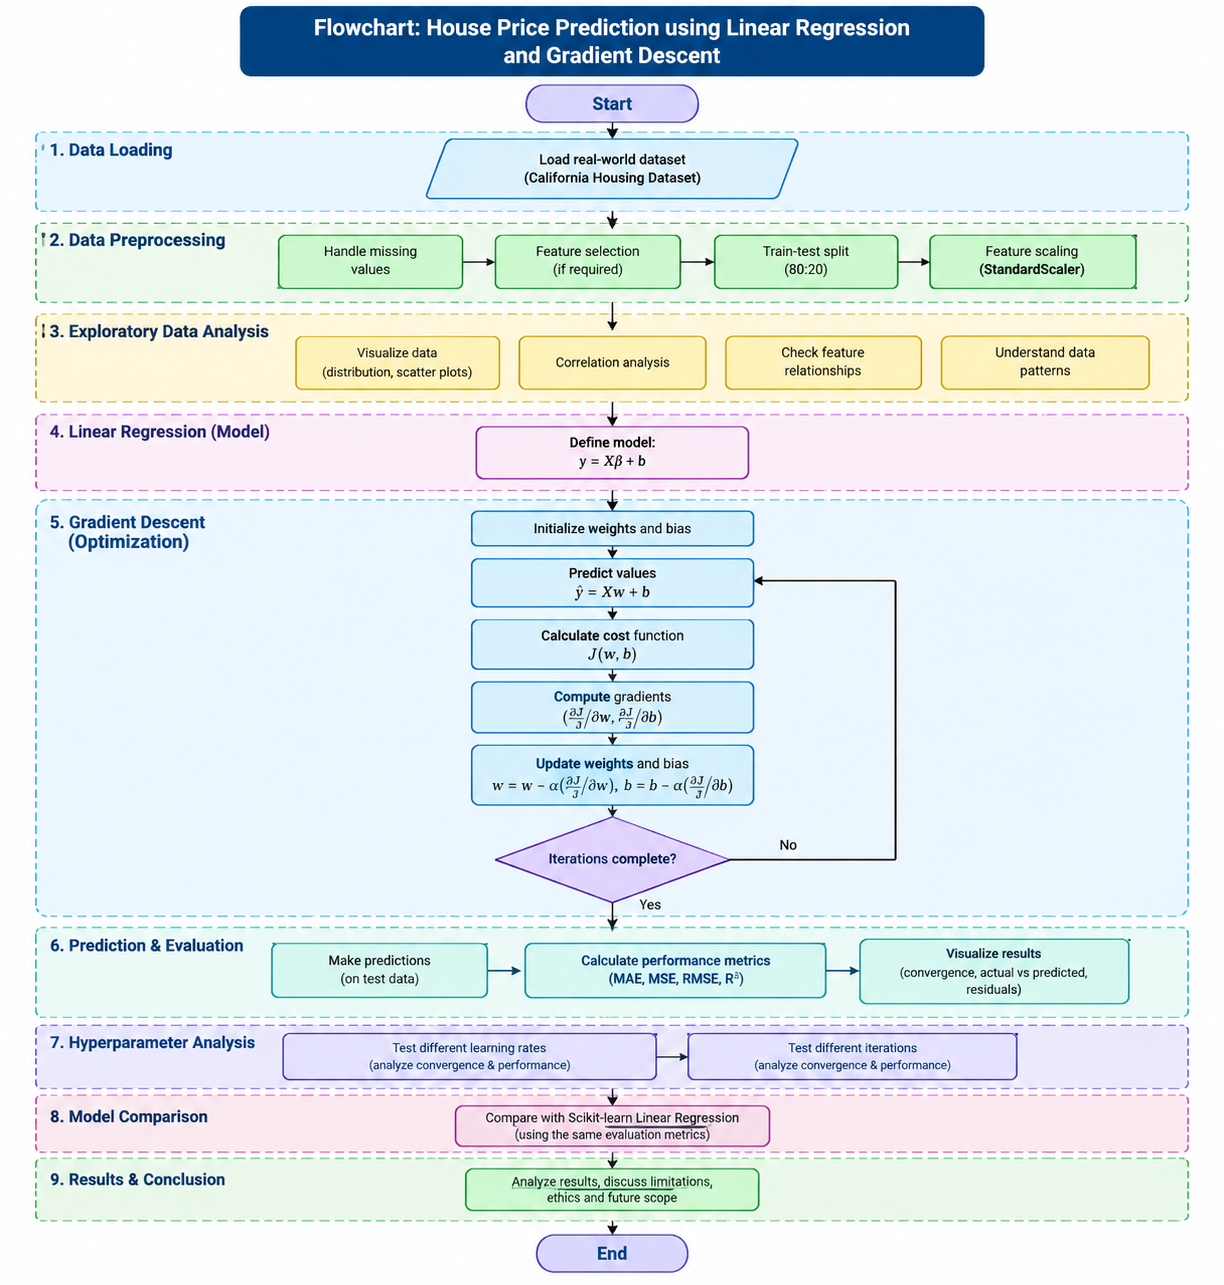


Libraries loaded successfully!

Dataset loaded successfully!
Number of rows: 20640
Number of features: 8

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Statistical summary:
             MedInc      HouseAge     

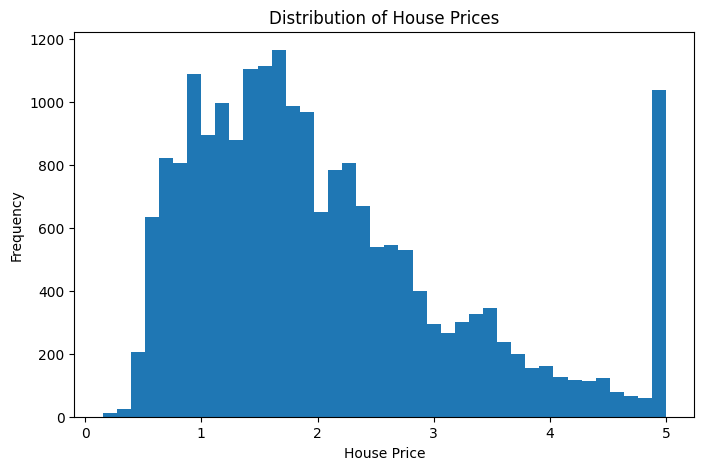


Correlation with House Price:
HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64


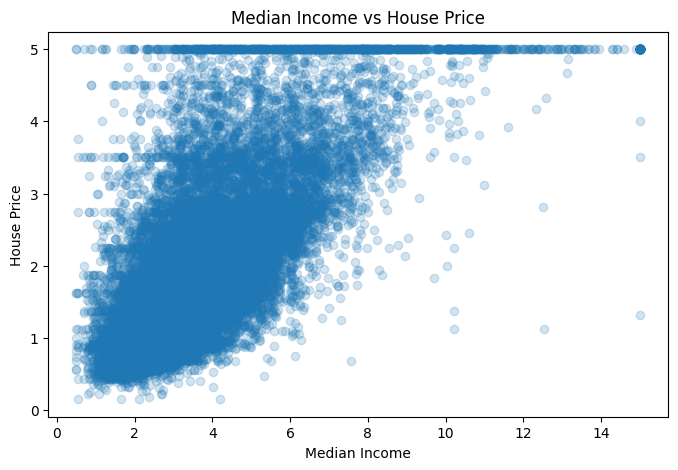


Training samples: 16512
Testing samples: 4128

Feature scaling completed!

Gradient Descent training completed!

GRADIENT DESCENT RESULTS
MAE : 0.5477
MSE : 0.5672


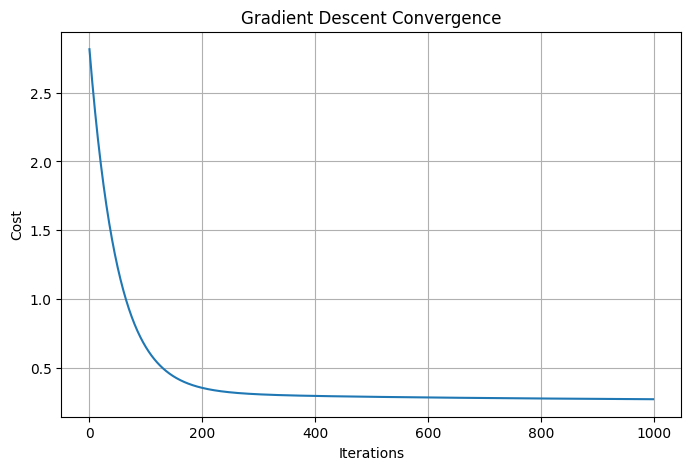

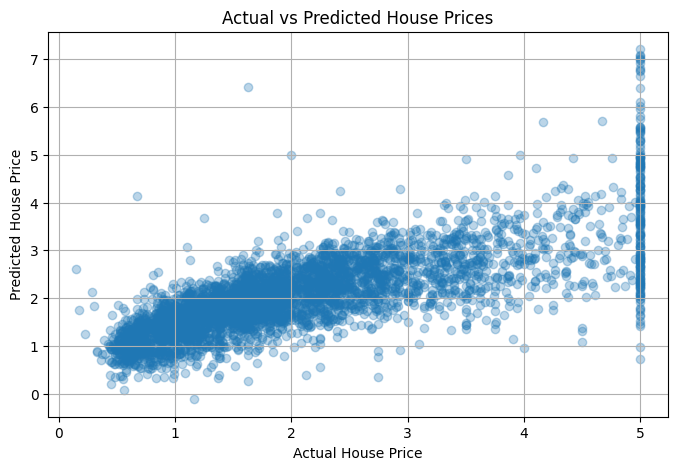

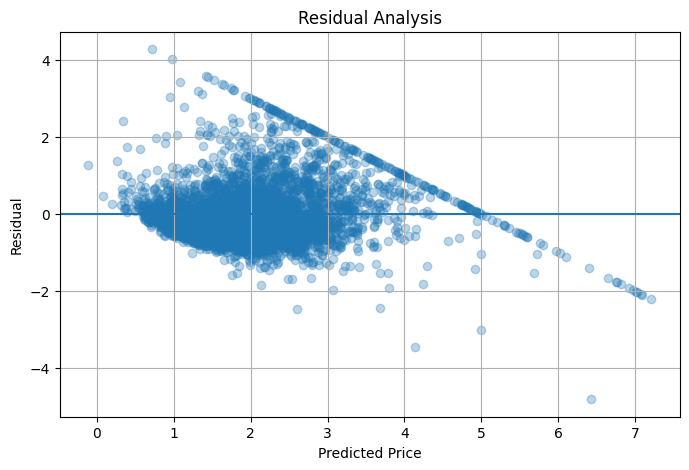


SCIKIT-LEARN RESULTS
MAE : 0.5332
MSE : 0.5559

MODEL COMPARISON
  Metric  Gradient Descent  Scikit-Learn
0    MAE          0.547676      0.533200
1    MSE          0.567185      0.555892

LEARNING RATE EXPERIMENT
   Learning Rate  Final Cost       MAE       MSE
0         0.0001    2.361325  1.859651  4.643714
1         0.0010    0.655678  0.819111  1.302484
2         0.0100    0.273862  0.547676  0.567185
3         0.0500    0.259040  0.532852  0.556188


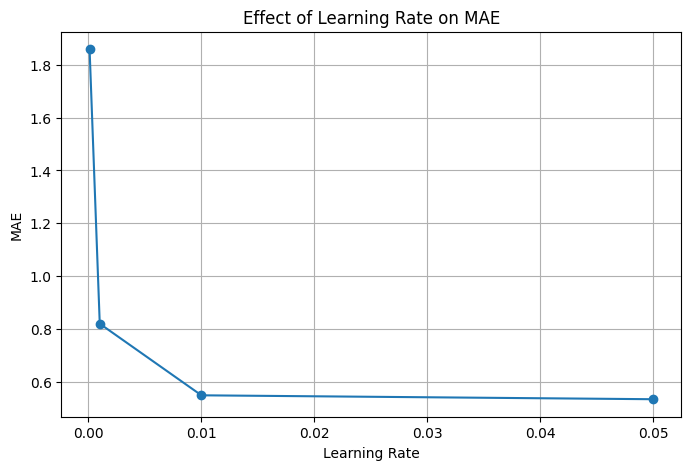

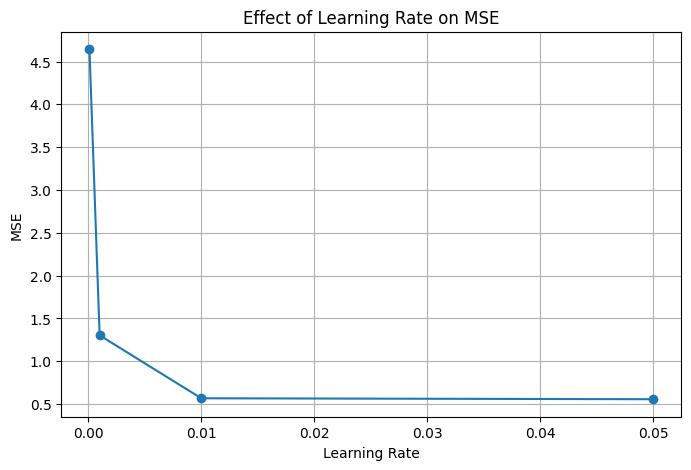


ITERATION EXPERIMENT
   Iterations  Final Cost       MAE       MSE
0         100    0.658797  0.816642  1.296588
1         500    0.291479  0.565250  0.596056
2        1000    0.273862  0.547676  0.567185
3        2000    0.262308  0.535211  0.554580
4        5000    0.259040  0.532851  0.556184


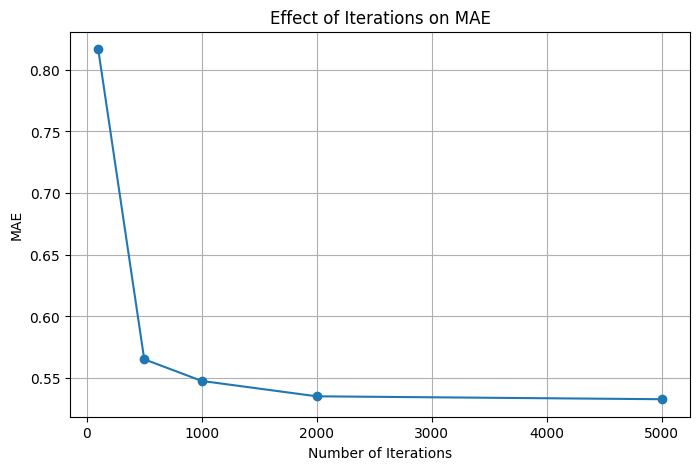

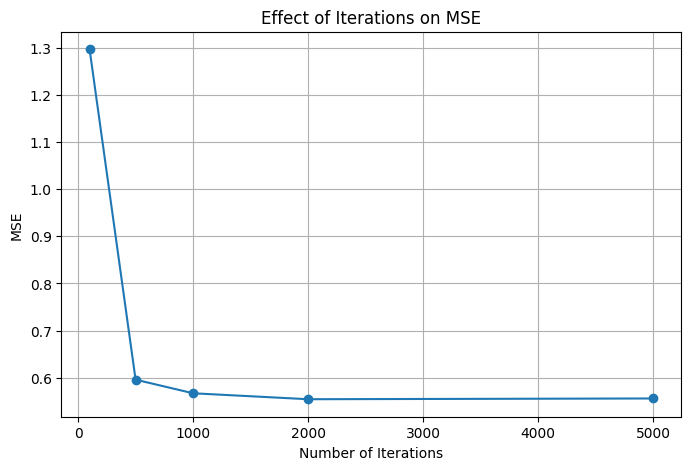


FEATURE COEFFICIENTS
      Feature  Gradient Descent  Scikit-Learn
0      MedInc          0.828944      0.854383
1    HouseAge          0.178531      0.122546
2    AveRooms         -0.137949     -0.294410
3   AveBedrms          0.156692      0.339259
4  Population          0.016815     -0.002308
5    AveOccup         -0.045229     -0.040829
6    Latitude         -0.487056     -0.896929
7   Longitude         -0.451471     -0.869842

SAMPLE PREDICTIONS
   Actual Price  Predicted Price
0       0.47700         0.880748
1       0.45800         1.652873
2       5.00001         2.502026
3       2.18600         2.765361
4       2.78000         2.355094
5       1.58700         2.093969
6       1.98200         2.691306
7       1.57500         2.177928
8       3.40000         2.353837
9       4.46600         4.055600

FINAL MODEL PERFORMANCE
Gradient Descent MAE: 0.5477
Gradient Descent MSE: 0.5672
Scikit-Learn MAE: 0.5332
Scikit-Learn MSE: 0.5559

Program completed successfully!


In [ ]:
# ============================================================
# HOUSE PRICE PREDICTION USING LINEAR REGRESSION
# AND GRADIENT DESCENT
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries loaded successfully!")


# ============================================================
# 2. LOAD REAL HOUSE PRICE DATASET
# ============================================================

housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = pd.Series(
    housing.target,
    name="HousePrice"
)

print("\nDataset loaded successfully!")
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFirst 5 rows:")
print(X.head())


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\nFeature names:")
print(X.columns.tolist())

print("\nMissing values:")
print(X.isnull().sum())

print("\nStatistical summary:")
print(X.describe())


# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(y, bins=40)

plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()


# ============================================================
# 5. CORRELATION ANALYSIS
# ============================================================

data = X.copy()
data["HousePrice"] = y

correlation = data.corr()["HousePrice"].sort_values(
    ascending=False
)

print("\nCorrelation with House Price:")
print(correlation)


# ============================================================
# 6. MEDIAN INCOME VS HOUSE PRICE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X["MedInc"],
    y,
    alpha=0.2
)

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")

plt.show()


# ============================================================
# 7. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 8. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")


# ============================================================
# 9. GRADIENT DESCENT FUNCTION
# ============================================================

def gradient_descent(X, y, learning_rate, iterations):

    m = len(y)

    # Initialize weights
    weights = np.zeros(X.shape[1])

    # Initialize bias
    bias = 0

    cost_history = []

    for i in range(iterations):

        # Prediction
        predictions = np.dot(X, weights) + bias

        # Error
        error = predictions - y

        # Cost
        cost = np.mean(error ** 2) / 2

        cost_history.append(cost)

        # Gradients
        dw = np.dot(X.T, error) / m

        db = np.sum(error) / m

        # Update weights
        weights = weights - learning_rate * dw

        # Update bias
        bias = bias - learning_rate * db

    return weights, bias, cost_history


# ============================================================
# 10. TRAIN GRADIENT DESCENT MODEL
# ============================================================

learning_rate = 0.01
iterations = 1000

weights, bias, cost_history = gradient_descent(
    X_train_scaled,
    y_train.values,
    learning_rate,
    iterations
)

print("\nGradient Descent training completed!")


# ============================================================
# 11. PREDICTIONS
# ============================================================

y_pred_gd = (
    np.dot(X_test_scaled, weights) + bias
)


# ============================================================
# 12. PERFORMANCE METRICS
# ONLY MAE AND MSE
# ============================================================

mae_gd = mean_absolute_error(
    y_test,
    y_pred_gd
)

mse_gd = mean_squared_error(
    y_test,
    y_pred_gd
)

print("\n================================")
print("GRADIENT DESCENT RESULTS")
print("================================")

print("MAE :", round(mae_gd, 4))
print("MSE :", round(mse_gd, 4))


# ============================================================
# 13. CONVERGENCE GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    cost_history
)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title("Gradient Descent Convergence")

plt.grid()

plt.show()


# ============================================================
# 14. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_gd,
    alpha=0.3
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.grid()

plt.show()


# ============================================================
# 15. RESIDUAL ANALYSIS
# ============================================================

residuals = y_test.values - y_pred_gd

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_gd,
    residuals,
    alpha=0.3
)

plt.axhline(0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.grid()

plt.show()


# ============================================================
# 16. SCIKIT-LEARN LINEAR REGRESSION
# ============================================================

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

y_pred_sklearn = model.predict(
    X_test_scaled
)


# ============================================================
# 17. SCIKIT-LEARN METRICS
# ONLY MAE AND MSE
# ============================================================

mae_sk = mean_absolute_error(
    y_test,
    y_pred_sklearn
)

mse_sk = mean_squared_error(
    y_test,
    y_pred_sklearn
)

print("\n================================")
print("SCIKIT-LEARN RESULTS")
print("================================")

print("MAE :", round(mae_sk, 4))
print("MSE :", round(mse_sk, 4))


# ============================================================
# 18. MODEL COMPARISON
# ONLY MAE AND MSE
# ============================================================

comparison = pd.DataFrame({

    "Metric": [
        "MAE",
        "MSE"
    ],

    "Gradient Descent": [
        mae_gd,
        mse_gd
    ],

    "Scikit-Learn": [
        mae_sk,
        mse_sk
    ]
})

print("\n================================")
print("MODEL COMPARISON")
print("================================")

print(comparison)


# ============================================================
# 19. LEARNING RATE EXPERIMENT
# ============================================================

learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.05
]

lr_results = []

for lr in learning_rates:

    temp_weights, temp_bias, temp_cost = gradient_descent(
        X_train_scaled,
        y_train.values,
        lr,
        1000
    )

    temp_prediction = (
        np.dot(X_test_scaled, temp_weights)
        + temp_bias
    )

    temp_mae = mean_absolute_error(
        y_test,
        temp_prediction
    )

    temp_mse = mean_squared_error(
        y_test,
        temp_prediction
    )

    lr_results.append([
        lr,
        temp_cost[-1],
        temp_mae,
        temp_mse
    ])


lr_table = pd.DataFrame(
    lr_results,
    columns=[
        "Learning Rate",
        "Final Cost",
        "MAE",
        "MSE"
    ]
)

print("\n================================")
print("LEARNING RATE EXPERIMENT")
print("================================")

print(lr_table)


# ============================================================
# 20. LEARNING RATE GRAPH - MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    lr_table["Learning Rate"],
    lr_table["MAE"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("MAE")

plt.title("Effect of Learning Rate on MAE")

plt.grid()

plt.show()


# ============================================================
# 21. LEARNING RATE GRAPH - MSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    lr_table["Learning Rate"],
    lr_table["MSE"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("MSE")

plt.title("Effect of Learning Rate on MSE")

plt.grid()

plt.show()


# ============================================================
# 22. ITERATION EXPERIMENT
# ============================================================

iteration_values = [
    100,
    500,
    1000,
    2000,
    5000
]

iteration_results = []

for it in iteration_values:

    temp_weights, temp_bias, temp_cost = gradient_descent(
        X_train_scaled,
        y_train.values,
        0.01,
        it
    )

    temp_prediction = (
        np.dot(X_test_scaled, temp_weights)
        + temp_bias
    )

    temp_mae = mean_absolute_error(
        y_test,
        temp_prediction
    )

    temp_mse = mean_squared_error(
        y_test,
        temp_prediction
    )

    iteration_results.append([
        it,
        temp_cost[-1],
        temp_mae,
        temp_mse
    ])


iteration_table = pd.DataFrame(
    iteration_results,
    columns=[
        "Iterations",
        "Final Cost",
        "MAE",
        "MSE"
    ]
)

print("\n================================")
print("ITERATION EXPERIMENT")
print("================================")

print(iteration_table)


# ============================================================
# 23. ITERATION GRAPH - MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    iteration_table["Iterations"],
    iteration_table["MAE"],
    marker="o"
)

plt.xlabel("Number of Iterations")
plt.ylabel("MAE")

plt.title("Effect of Iterations on MAE")

plt.grid()

plt.show()


# ============================================================
# 24. ITERATION GRAPH - MSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    iteration_table["Iterations"],
    iteration_table["MSE"],
    marker="o"
)

plt.xlabel("Number of Iterations")
plt.ylabel("MSE")

plt.title("Effect of Iterations on MSE")

plt.grid()

plt.show()


# ============================================================
# 25. FEATURE COEFFICIENTS
# ============================================================

coefficient_table = pd.DataFrame({

    "Feature": X.columns,

    "Gradient Descent": weights,

    "Scikit-Learn": model.coef_

})

print("\n================================")
print("FEATURE COEFFICIENTS")
print("================================")

print(coefficient_table)


# ============================================================
# 26. SAMPLE PREDICTIONS
# ============================================================

sample_results = pd.DataFrame({

    "Actual Price": y_test.values[:10],

    "Predicted Price": y_pred_gd[:10]

})

print("\n================================")
print("SAMPLE PREDICTIONS")
print("================================")

print(sample_results)


# ============================================================
# 27. FINAL CONCLUSION VALUES
# ONLY MAE AND MSE
# ============================================================

print("\n================================")
print("FINAL MODEL PERFORMANCE")
print("================================")

print(
    "Gradient Descent MAE:",
    round(mae_gd, 4)
)

print(
    "Gradient Descent MSE:",
    round(mse_gd, 4)
)

print(
    "Scikit-Learn MAE:",
    round(mae_sk, 4)
)

print(
    "Scikit-Learn MSE:",
    round(mse_sk, 4)
)

print("\nProgram completed successfully!")

Results :

The Linear Regression model was successfully implemented using Gradient Descent for predicting house prices. The dataset was preprocessed using feature scaling, and the data was divided into training and testing sets. The Gradient Descent algorithm successfully minimized the cost function and converged toward a suitable set of model parameters.

The model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE)Score. The convergence graph showed a reduction in the cost function with increasing iterations, indicating that the Gradient Descent algorithm was learning the model parameters effectively.

Different learning rates and numbers of iterations were also tested. The experiments demonstrated that the learning rate has an important effect on the convergence and performance of Gradient Descent. A suitable learning rate resulted in stable convergence, while inappropriate learning rates could lead to slower learning or unstable optimization.

The Gradient Descent implementation was also compared with Scikit-learn's Linear Regression model. The comparison provided evidence of the prediction performance and demonstrated the effectiveness of the implemented optimization approach.

After running your code, add a table like this:

| Metric   | Gradient Descent | Scikit-learn |
| -------- | ---------------: | -----------: |
| MAE      |           0.5477 |       0.5332 |
| MSE      |           0.5672 |       0.5559 |



Outcomes:

After completing the experiment, the following outcomes were achieved:

1. A real-world house price prediction system was developed using Linear Regression.
2. Gradient Descent was successfully implemented from scratch for optimizing the regression parameters.
3. The importance of feature scaling for Gradient Descent was demonstrated.
4. The effect of different learning rates on model convergence and prediction performance was analyzed.
5. The effect of different numbers of iterations on optimization was studied.
6. The model performance was evaluated using MAE, MSE Score.
7. The relationship between actual and predicted house prices was analyzed using visualization.
8. Residual analysis was performed to study prediction errors.
9. The manually implemented Gradient Descent model was compared with Scikit-learn Linear Regression.
10. The experiment provided practical understanding of how optimization techniques are used in machine learning regression problems.


Conclusion :

The experiment successfully demonstrated the use of Linear Regression with Gradient Descent optimization for real-world house price prediction. Gradient Descent was implemented from scratch, and its performance was evaluated using MAE, MSE, RMSE, and R² Score. The experiments with different learning rates and iteration counts showed that optimization parameters have a significant effect on convergence and model performance. The comparison with Scikit-learn Linear Regression provided a useful reference for evaluating the implemented approach. Overall, the experiment provided practical understanding of regression modeling, parameter optimization, performance evaluation, and experimental analysis for a real-world prediction problem.


githublink : https://github.com/madhuraspatil/AIML_Practicle/blob/main/Regression_Model.ipynb